## 1. What this notebook computes

At a temperature $T > 0$ the particles of the Kohn-Sham gas no longer fill exactly
the lowest levels: each level is occupied with the **Fermi-Dirac** probability
$f = 1/(1 + e^{(\varepsilon - \mu)/T})$, where the **chemical potential** $\mu$ is
fixed by the particle number. This is Mermin's finite-temperature version of
Kohn-Sham theory. The Revision record holds 135 such states (three particle numbers,
three couplings, five slices of the history, three temperatures). This notebook

- runs the Rust solver for the free states ($\lambda = 0$) of $N = 8$ and $N = 136$
  and reads its levels;
- recomputes from these levels, in plain Python, $\mu$ (at 40 digits with mpmath),
  the energy $E$, the entropy $S$, the free energy $F = E - TS$, the grand
  potential $\Omega$, the heat capacity $C_V$ and $dN/d\mu$, and compares all of
  them with the record;
- explains why the solver computes $\mu$ from a **balance of particles and holes**
  instead of the direct count, and shows the difference;
- draws $\mu$, $F$, $S$ and $C_V$ as continuous functions of $T$, the occupations at
  three temperatures, the sea-hole diagnostic of the filling convention, and the
  effect of the interaction on $F$.

It draws seven figures and takes about half a minute.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 15d (Thermodynamics of the Kohn-Sham gas along the deflating history) is the
file `Revision/textbook/notebooks/15d_thermodynamics.ipynb` of the repository
Dirac_claude. It runs the Rust Kohn-Sham solver for the free thermal states N = 8 and N =
136 of dirac16complex at the slices of the deflating history, recomputes from the
solver's levels the chemical potential (at 40 digits and with the well-conditioned
double-precision balance), the energy, entropy, free energy, grand potential, heat
capacity and the sea-hole diagnostic of the committed Revision record, and draws the
chemical potential, free energy, entropy and heat capacity as functions of the
temperature. The solver writes its output files (about 0.7 MB) into the folder
`Revision/kohn_sham/solver/target/textbook_15d`, which git ignores. It needs a computer
with Windows 11, macOS or Linux, an internet connection for the installation, the program
Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these
packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib
3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and
nbconvert 7.16.6. The notebook itself imports numpy, mpmath and matplotlib; the other
packages run Jupyter, the program that shows and runs notebooks. It also needs Rust (the
program cargo, version 1.91.1 or newer), because it runs the Rust program
revision_ks_solver, which is part of the repository and is built on your computer.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (about 130 MB; the folder then takes about 400
MB of disk space) into the folder Dirac_claude inside your home folder, create a private
Python environment in the folder dirac-book-env inside your home folder (a private
environment is a folder with its own copy of Python and of the packages, so that nothing
else on your computer is changed), activate it (from then on the commands `python` and
`jupyter` typed in this terminal are those of the environment, and the prompt starts with
(dirac-book-env)), and install the packages at the pinned versions (this downloads about
90 MB and takes a few minutes; the environment takes about 400 MB of disk space). If you
have done this step before, for this or for another notebook, skip it and go to Step 4;
to get the newest version of the repository, run `git pull` in the repository folder
after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Install Rust and build the Rust program (Rust once per computer, the build once
per program).**

Windows: download `rustup-init.exe` from https://rustup.rs, run it and accept the default
choices; if it reports that the Visual Studio C++ Build Tools are missing, let it install
them (or install the workload "Desktop development with C++" from
https://visualstudio.microsoft.com/visual-cpp-build-tools/ and run `rustup-init.exe`
again). macOS and Linux: run the command below and accept the default choice (on Linux
first run `sudo apt install build-essential`, which provides the linker that Rust needs).

macOS (zsh) and Linux (bash):

    curl --proto "=https" --tlsv1.2 -sSf https://sh.rustup.rs | sh

Then close the terminal, open a new one, do Step 4 again, and check the version of cargo;
it must print 1.91.1 or a newer version:

Windows, macOS and Linux:

    cargo --version

Build the program with the following command, in the repository folder (the same command
on all three systems):

Windows, macOS and Linux:

    cargo build --release --manifest-path Revision/kohn_sham/solver/Cargo.toml

The first build takes about 1 minute; later builds reuse the result and take a few
seconds. The program is then the file
`Revision/kohn_sham/solver/target/release/revision_ks_solver` (on Windows with the ending
`.exe`). The notebook runs the same build command itself before it uses the program (it
takes a second when the program is up to date), so the notebook also works if you skip
this build; building here first shows any problem with Rust before the notebook starts.

**Step 6. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 15d_thermodynamics.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 30 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 7. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 15d_thermodynamics.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
15d_thermodynamics.ipynb` (in the same folder, without running the cells again) to read
the printed lines and see the figures.

**Step 8. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/15d.captions.json`
- `Revision/textbook/figures/15d_1_root_conditioning.png`
- `Revision/textbook/figures/15d_2_chemical_potential.png`
- `Revision/textbook/figures/15d_3_free_energy_entropy.png`
- `Revision/textbook/figures/15d_4_heat_capacity.png`
- `Revision/textbook/figures/15d_5_occupations.png`
- `Revision/textbook/figures/15d_6_sea_holes.png`
- `Revision/textbook/figures/15d_7_interaction_free_energy.png`

It changes no other file of the repository except the Rust build folder `target` next to
each `Cargo.toml` it builds; running it headless or saving it in JupyterLab also rewrites
the notebook file itself. It does not use the internet while it runs. The files it writes
are the same files that are stored in the repository (on another computer a figure may
differ in a few bytes, which is harmless). To get the stored versions back, run this
command in the repository folder (it also undoes every change you made yourself in the
folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS every figure file of this notebook exists
    ALL 14 CHECKS PASSED (notebook 15d)

and the notebook must show 7 figures below the cells that draw them.

**Step 9. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/15d_thermodynamics.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "cargo is not recognized" or "command not found: cargo" or "cargo was not found": open
  a new terminal after installing Rust, do Step 4 again, and start JupyterLab from this
  terminal.
- "linker link.exe not found" (Windows) or "linker cc not found" (Linux): install the C++
  Build Tools (Windows) or build-essential (Linux) as described in Step 5 and build
  again.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 15d (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 15d (Thermodynamics of the Kohn-Sham gas along the deflating history) is the
# file Revision/textbook/notebooks/15d_thermodynamics.ipynb of the repository
# Dirac_claude. It runs the Rust Kohn-Sham solver for the free thermal states N = 8 and N
# = 136 of dirac16complex at the slices of the deflating history, recomputes from the
# solver's levels the chemical potential (at 40 digits and with the well-conditioned
# double-precision balance), the energy, entropy, free energy, grand potential, heat
# capacity and the sea-hole diagnostic of the committed Revision record, and draws the
# chemical potential, free energy, entropy and heat capacity as functions of the
# temperature. The solver writes its output files (about 0.7 MB) into the folder
# Revision/kohn_sham/solver/target/textbook_15d, which git ignores. It needs a computer
# with Windows 11, macOS or Linux, an internet connection for the installation, the
# program Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5)
# with these packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0,
# matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0
# and nbconvert 7.16.6. The notebook itself imports numpy, mpmath and matplotlib; the
# other packages run Jupyter, the program that shows and runs notebooks. It also needs
# Rust (the program cargo, version 1.91.1 or newer), because it runs the Rust program
# revision_ks_solver, which is part of the repository and is built on your computer.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (about 130 MB; the folder then takes about
# 400 MB of disk space) into the folder Dirac_claude inside your home folder, create a
# private Python environment in the folder dirac-book-env inside your home folder (a
# private environment is a folder with its own copy of Python and of the packages, so
# that nothing else on your computer is changed), activate it (from then on the commands
# python and jupyter typed in this terminal are those of the environment, and the prompt
# starts with (dirac-book-env)), and install the packages at the pinned versions (this
# downloads about 90 MB and takes a few minutes; the environment takes about 400 MB of
# disk space). If you have done this step before, for this or for another notebook, skip
# it and go to Step 4; to get the newest version of the repository, run git pull in the
# repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. INSTALL RUST AND BUILD THE RUST PROGRAM (RUST ONCE PER COMPUTER, THE BUILD ONCE
# PER PROGRAM).
#
# Windows: download rustup-init.exe from https://rustup.rs, run it and accept the default
# choices; if it reports that the Visual Studio C++ Build Tools are missing, let it
# install them (or install the workload "Desktop development with C++" from
# https://visualstudio.microsoft.com/visual-cpp-build-tools/ and run rustup-init.exe
# again). macOS and Linux: run the command below and accept the default choice (on Linux
# first run sudo apt install build-essential, which provides the linker that Rust needs).
#
# macOS (zsh) and Linux (bash):
#     curl --proto "=https" --tlsv1.2 -sSf https://sh.rustup.rs | sh
#
# Then close the terminal, open a new one, do Step 4 again, and check the version of
# cargo; it must print 1.91.1 or a newer version:
#
# Windows, macOS and Linux:
#     cargo --version
#
# Build the program with the following command, in the repository folder (the same
# command on all three systems):
#
# Windows, macOS and Linux:
#     cargo build --release --manifest-path Revision/kohn_sham/solver/Cargo.toml
#
# The first build takes about 1 minute; later builds reuse the result and take a few
# seconds. The program is then the file
# Revision/kohn_sham/solver/target/release/revision_ks_solver (on Windows with the ending
# .exe). The notebook runs the same build command itself before it uses the program (it
# takes a second when the program is up to date), so the notebook also works if you skip
# this build; building here first shows any problem with Rust before the notebook starts.
#
# STEP 6. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 15d_thermodynamics.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 30
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 7. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 15d_thermodynamics.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 15d_thermodynamics.ipynb (in the same folder, without running the cells again) to read
# the printed lines and see the figures.
#
# STEP 8. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/15d.captions.json
# - Revision/textbook/figures/15d_1_root_conditioning.png
# - Revision/textbook/figures/15d_2_chemical_potential.png
# - Revision/textbook/figures/15d_3_free_energy_entropy.png
# - Revision/textbook/figures/15d_4_heat_capacity.png
# - Revision/textbook/figures/15d_5_occupations.png
# - Revision/textbook/figures/15d_6_sea_holes.png
# - Revision/textbook/figures/15d_7_interaction_free_energy.png
#
# It changes no other file of the repository except the Rust build folder target next to
# each Cargo.toml it builds; running it headless or saving it in JupyterLab also rewrites
# the notebook file itself. It does not use the internet while it runs. The files it
# writes are the same files that are stored in the repository (on another computer a
# figure may differ in a few bytes, which is harmless). To get the stored versions back,
# run this command in the repository folder (it also undoes every change you made
# yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS every figure file of this notebook exists
#     ALL 14 CHECKS PASSED (notebook 15d)
#
# and the notebook must show 7 figures below the cells that draw them.
#
# STEP 9. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/15d_thermodynamics.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "cargo is not recognized" or "command not found: cargo" or "cargo was not found":
#   open a new terminal after installing Rust, do Step 4 again, and start JupyterLab from
#   this terminal.
# - "linker link.exe not found" (Windows) or "linker cc not found" (Linux): install the
#   C++ Build Tools (Windows) or build-essential (Linux) as described in Step 5 and build
#   again.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell
import shutil  # finds the program cargo
import subprocess  # runs cargo and the Rust programs

NOTEBOOK_ID = "15d"  # this notebook: chapter 15, example d


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


def rust_program(manifest, binary):
    """Build the Rust program binary of the crate whose Cargo.toml is manifest (a
    repository path) with "cargo build --release" (about a second when it is up to date;
    minutes the first time) and return the path of the program."""
    if shutil.which("cargo") is None:
        raise FileNotFoundError(
            "cargo was not found: install Rust from https://rustup.rs, open a new "
            "terminal, activate the environment and start JupyterLab again")
    crate = (REPO / manifest).parent  # the folder that holds Cargo.toml
    completed = subprocess.run(
        ["cargo", "build", "--release", "--manifest-path", str(REPO / manifest),
         "--target-dir", str(crate / "target")],
        capture_output=True, text=True, encoding="utf-8", errors="replace")
    if completed.returncode != 0:  # show the end of cargo's error message
        print(completed.stderr[-3000:])
        raise RuntimeError(f"cargo build failed for {manifest}")
    for file_name in (binary, binary + ".exe"):  # Linux and macOS; Windows
        path = crate / "target" / "release" / file_name
        if path.is_file():
            say(f"Rust program {binary} is built and ready.")
            return path
    raise FileNotFoundError(f"cargo built {manifest} but {binary} is missing")

say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 15d complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Temperature** $T$: measured in units of the mass $m$ (Boltzmann's constant is
  1).
- **Fermi-Dirac occupation** $f(x) = 1/(1 + e^{x})$ with $x = (\varepsilon - \mu)/T$:
  the probability that a level of energy $\varepsilon$ is occupied. It is 1 far below
  $\mu$, 0 far above, and $1/2$ at $\varepsilon = \mu$. A useful identity:
  $1 - f(x) = f(-x)$.
- **Chemical potential** $\mu$: the number that makes the occupations add up to the
  particle number, $\sum g f = N$ ($g$ the degeneracy of a level).
- **Entropy** $S = -\sum g[f\ln f + (1 - f)\ln(1 - f)]$: a measure of how many
  microscopic arrangements the gas can take.
- **Free energy** $F = E - TS$ and **grand potential** $\Omega = F - \mu N$.
- **Heat capacity** $C_V = dE/dT = T\,dS/dT$ at fixed $N$: how much energy one
  unit of temperature costs.
- **Activated**: a gas whose lowest empty level lies a gap $\Delta$ above the
  highest occupied one; at $T \ll \Delta$ the thermal excitations are suppressed like
  $e^{-\Delta/(2T)}$.
- **Hole**: an empty place in a level that is normally occupied.
- **Sea**: the levels of the negative branch, which the filling CONVENTION of the
  record leaves out (normal ordering); **sea holes** would be thermal antiparticles.
- **Double precision**: the computer's usual numbers, with about 16 significant
  digits; **40 digits**: mpmath's numbers with as many digits as asked for.
- **Conditioning**: how strongly a result reacts to small errors of the input.

## 4. The physical and mathematical situation

The Kohn-Sham states of dirac16complex live in the author's metric, with 3-space
$x_1, x_2, x_3$ inflating like $e^{a_4}$, the three extra times $x_5, x_6, x_7$
deflating like $e^{-a_4}$, the time $x_4$ and the hidden direction $x_8$ (coordinate
$y$). The history $a_4 = AHx_4$ is a PRESCRIBED BACKGROUND, and each thermal state
is an instantaneous state at one slice $a_{4,0}$.

**Mermin's functional** (Revision record ks-theory.json, thermodynamics): with the
levels $\varepsilon_i$ (degeneracy $g_i$) of the Kohn-Sham Hamiltonian,

$$\sum_i g_i f_i = N, \quad E = \sum_i g_i f_i\varepsilon_i -
2\,\mathrm{Vol}_7\!\int e^{6Hy}e_{int}\,dy, \quad
S = -\sum_i g_i[f_i\ln f_i + (1 - f_i)\ln(1 - f_i)],$$
$$F = E - TS, \qquad \Omega = -T\sum_i g_i\ln(1 + e^{-(\varepsilon_i - \mu)/T})
- 2\,\mathrm{Vol}_7\!\int e^{6Hy}e_{int}\,dy = F - \mu N .$$

Without interaction ($\lambda = 0$) the levels do not depend on $T$ and $e_{int} = 0$,
so everything follows from the levels. Then the heat capacity has a closed form:
differentiating $\sum g f = N$ at fixed $N$ gives $d\mu/dT$, and inserting it into
$dE/dT$ gives, with $w_i = g_i f_i(1 - f_i)$ and $d_i = \varepsilon_i - \mu$,

$$C_V = \frac{1}{T^2}\left[\sum_i w_i d_i^2 - \frac{(\sum_i w_i d_i)^2}{\sum_i
w_i}\right], \qquad \frac{dN}{d\mu} = \frac{1}{T}\sum_i w_i .$$

(Line by line: $df/dx = -f(1-f)$; $dx_i/dT = -d_i/T^2 - (d\mu/dT)/T$; fixed $N$ means
$\sum w_i\,dx_i/dT = 0$, so $d\mu/dT = -\sum w_i d_i/(T\sum w_i)$; then
$dE/dT = -\sum w_i\varepsilon_i\,dx_i/dT$, and replacing $\varepsilon_i$ by $d_i$
changes nothing because $\sum w_i\,dx_i/dT = 0$.)

**The filling convention** (a CONVENTION whose justification is OPEN): particles fill
only the positive branch and the zero modes; the negative branch (the sea) is never
occupied thermally. The record measures how good this is: the **sea holes** that the
sea's brane band would carry at the same $\mu$ and $T$.

**Parameters**: $H = m = 1$, $L = 3$, $\Delta k = 0.25$, $T = 0.01, 0.02, 0.05$; $N$
counts the doubled system (universe and Z2 image, the brane being ASSUMED).

## 5. Building the solver and computing the free thermal states

The next cell builds the solver and defines `thermal_state`, which runs
`revision_ks_solver single` with `--T` (the temperature) and `--margin 0.2` (the
label set of the canonical matrix, so that the state is exactly the recorded one),
and with `--mermin-levels`, which writes the final levels as decimal numbers that
read back into exactly the solver's numbers. It returns the solver's $\mu$, its
levels with degeneracies, and the full level list (shell, block type, parity,
label, energy, degeneracy, occupation). The cell then computes the 18 free states
$N = 8, 136$, $a_{4,0} = 0, 1, 2$, $T = 0.01, 0.02, 0.05$, and two more for $N = 136$
at $a_{4,0} = 0.5$ and $1.5$ ($T = 0.05$), and compares each $\mu$ with the record.

In [2]:
import csv  # reads the tables (CSV files)
import math  # exp, log for single numbers

import mpmath  # numbers with 40 digits
import numpy as np  # arrays of numbers

program = rust_program("Revision/kohn_sham/solver/Cargo.toml", "revision_ks_solver")
RUN_FOLDER = REPO / "Revision/kohn_sham/solver/target/textbook_15d"  # git ignores it
RUN_FOLDER.mkdir(parents=True, exist_ok=True)
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300",
           "#4a3aa7", "#e34948"]  # the colours of the figures, in a fixed order
SHADES = {0.0: "#86b6ef", 0.5: "#5598e7", 1.0: "#2a78d6", 1.5: "#1c5cab",
          2.0: "#104281"}  # one shade of blue per slice, light to dark
TEMPS = (0.01, 0.02, 0.05)


def state_id(n, a4, t, tag="lam0"):
    return f"N{n}_{tag}_a{round(10 * a4):02d}_T{round(1000 * t)}"


def thermal_state(n, a4, t):
    """Run the solver for one free thermal state; (mu, eps, deg, levels)."""
    name = state_id(n, a4, t)
    out, lev = RUN_FOLDER / f"{name}.json", RUN_FOLDER / f"{name}-levels.json"
    done = subprocess.run(
        [str(program), "single", "--root", str(REPO), "--m", "1", "--lambda", "0",
         "--a4", repr(a4), "--N", repr(float(n)), "--T", repr(t), "--margin", "0.2",
         "--out", str(out), "--mermin-levels", str(lev)],
        capture_output=True, text=True)
    if done.returncode != 0:
        raise RuntimeError(f"the solver failed for {name}: {done.stderr[-500:]}")
    exact = json.loads(lev.read_text(encoding="utf-8"))
    full = json.loads(out.read_text(encoding="utf-8"))
    eps = [float(e) for e, _ in exact["levels_eps_deg"]]  # exactly the solver's
    deg = [float(g) for _, g in exact["levels_eps_deg"]]
    return float(exact["mu"]), eps, deg, full["levels_n2_j_parity_label_eps_deg_f"]


THERMO = "Revision/kohn_sham/results/thermo/thermodynamics.csv"
with open(repository_file(THERMO), newline="", encoding="utf-8") as handle:
    record = {row["id"]: row for row in csv.DictReader(handle)}
states = {}
for n in (8, 136):
    for a4 in (0.0, 1.0, 2.0):
        for t in TEMPS:
            states[(n, a4, t)] = thermal_state(n, a4, t)
for a4 in (0.5, 1.5):
    states[(136, a4, 0.05)] = thermal_state(136, a4, 0.05)
worst_mu = max(abs(mu - float(record[state_id(n, a4, t)]["mu"]))
               for (n, a4, t), (mu, _, _, _) in states.items())
report("free thermal states computed", len(states))
report("largest |mu(solver now) - mu(record)|", f"{worst_mu:.1e}")
check(worst_mu < 1e-12, f"the solver reproduces the recorded mu of {len(states)} states",
      record=f"{THERMO}, column mu")

Rust program revision_ks_solver is built and ready.
RESULT free thermal states computed = 20
RESULT largest |mu(solver now) - mu(record)| = 5.6e-17
PASS the solver reproduces the recorded mu of 20 states
     reproduces Revision/kohn_sham/results/thermo/thermodynamics.csv, column mu


## 6. The chemical potential at 40 digits, and the other functions of state

The next cell solves $\sum g f = N$ again with mpmath at 40 significant digits
(Newton's method started at the solver's $\mu$), so that rounding plays no role at
all. The solver's $\mu$ must lie within its own **rounding bound** (column
`mu_rounding_bound` of the record) of this exact root. Then it computes $E$, $S$,
$F$, $\Omega$, $C_V$ (closed form) and $dN/d\mu$ in double precision at the solver's
$\mu$ and compares them with the record. The record's $C_V$ is a numerical
derivative $T\,dS/dT$ (Richardson differences), so the comparison allows
$10^{-4}$; the others agree to $10^{-12}$.

In [3]:
def exact_root(eps, deg, n, t, guess):
    """The root of sum g f = N with 40 significant digits (Newton's method)."""
    with mpmath.workdps(40):
        levels = [(mpmath.mpf(e), mpmath.mpf(g)) for e, g in zip(eps, deg)]
        temp, mu = mpmath.mpf(t), mpmath.mpf(guess)
        for _ in range(60):
            occ = [(g, 1 / (1 + mpmath.exp((e - mu) / temp))) for e, g in levels]
            count = sum(g * f for g, f in occ) - n
            slope = sum(g * f * (1 - f) for g, f in occ) / temp  # dN/dmu
            step = count / slope
            mu -= step
            if abs(step) < mpmath.mpf(10) ** -36:
                break
        return mu


def functions_of_state(eps, deg, mu, t):
    """E, S, F, Omega, C_V, dN/dmu of a free state (double precision, stable forms)."""
    e, g = np.array(eps), np.array(deg)
    x = (e - mu) / t
    small = np.exp(-np.abs(x))  # e^{-|x|}, never overflows
    f_abs = small / (1.0 + small)  # f(|x|)
    f = np.where(x > 0, f_abs, 1.0 - f_abs)  # f(x)
    energy = float(np.sum(g * f * e))
    # -[f ln f + (1-f) ln(1-f)] = ln(1 + e^{-|x|}) + |x| f(|x|)
    entropy = float(np.sum(g * (np.log1p(small) + np.abs(x) * f_abs)))
    # ln(1 + e^{-x}) = max(-x, 0) + ln(1 + e^{-|x|})
    omega = -t * float(np.sum(g * (np.maximum(-x, 0.0) + np.log1p(small))))
    w = g * f_abs * (1.0 - f_abs)  # g f (1 - f), the same for x and -x
    d = e - mu
    cv = float((np.sum(w * d * d) - np.sum(w * d) ** 2 / np.sum(w)) / t ** 2)
    return energy, entropy, energy - t * entropy, omega, cv, float(np.sum(w) / t)


rel = lambda a, b: abs(a - b) / max(abs(b), 1.0)  # relative to max(|b|, 1)
worst = {"root": 0.0, "E S F Omega": 0.0, "C_V": 0.0, "dN/dmu": 0.0}
for (n, a4, t), (mu, eps, deg, _) in states.items():
    row = record[state_id(n, a4, t)]
    root = exact_root(eps, deg, n, t, mu)
    worst["root"] = max(worst["root"],
                        float(abs(mu - root)) / float(row["mu_rounding_bound"]))
    e_, s_, f_, o_, cv, dn = functions_of_state(eps, deg, mu, t)
    worst["E S F Omega"] = max(worst["E S F Omega"], rel(e_, float(row["E"])),
                               rel(s_, float(row["entropy"])), rel(f_, float(row["F"])),
                               rel(o_, float(row["Omega_direct"])))
    worst["C_V"] = max(worst["C_V"], abs(cv / float(row["C_V"]) - 1.0))
    worst["dN/dmu"] = max(worst["dN/dmu"], abs(dn / float(row["dN_dmu"]) - 1.0))
report("largest |mu - 40-digit root| / recorded rounding bound", f"{worst['root']:.2f}")
for key in ("E S F Omega", "C_V", "dN/dmu"):
    report(f"largest relative difference, {key}", f"{worst[key]:.1e}")
check(worst["root"] <= 1.0, "mu lies within its rounding bound of the 40-digit root",
      record="Revision/kohn_sham/reports/ks-rust-mermin-roots.json and "
             f"{THERMO}, column mu_rounding_bound")
check(worst["E S F Omega"] < 1e-12,
      f"E, S, F and Omega of {len(states)} states reproduced",
      record=f"{THERMO}, columns E, entropy, F, Omega_direct")
check(worst["C_V"] < 1e-4, "the closed-form C_V reproduces the recorded T dS/dT",
      record=f"{THERMO}, column C_V")
check(worst["dN/dmu"] < 1e-9, "dN/dmu reproduced", record=f"{THERMO}, column dN_dmu")

RESULT largest |mu - 40-digit root| / recorded rounding bound = 0.15
RESULT largest relative difference, E S F Omega = 3.6e-14
RESULT largest relative difference, C_V = 1.6e-05
RESULT largest relative difference, dN/dmu = 2.0e-15
PASS mu lies within its rounding bound of the 40-digit root
     reproduces Revision/kohn_sham/reports/ks-rust-mermin-roots.json and
    Revision/kohn_sham/results/thermo/thermodynamics.csv, column mu_rounding_bound
PASS E, S, F and Omega of 20 states reproduced
     reproduces Revision/kohn_sham/results/thermo/thermodynamics.csv, columns E, entropy,
    F, Omega_direct
PASS the closed-form C_V reproduces the recorded T dS/dT
     reproduces Revision/kohn_sham/results/thermo/thermodynamics.csv, column C_V
PASS dN/dmu reproduced
     reproduces Revision/kohn_sham/results/thermo/thermodynamics.csv, column dN_dmu


## 7. Why the solver uses a balance instead of the direct count

Near a closed shell at low temperature almost every level is either full ($f
\approx 1$) or empty ($f \approx 0$). The direct count $\sum g f - N$ then adds
numbers close to 1 and subtracts $N$: in double precision the result is a multiple
of the rounding step of $N$ (about $10^{-15}$), while the true value changes with
$\mu$ only at the rate $dN/d\mu$, which for $N = 8$ at $a_{4,0} = 0$,
$T = 0.01$ is about $1.2 \times 10^{-6}$. So the direct count cannot locate $\mu$
better than about $10^{-15}/(1.2 \times 10^{-6})$, a few times $10^{-10}$ to
$10^{-9}$ (the record found an error of $8.3 \times 10^{-10}$ in the solver's
earlier version, which used the direct count). The solver
instead balances the thermal **particles** above the filled levels against the
thermal **holes** below them, $P = \sum_{above} g f(x)$ and $H_l = \sum_{below} g
f(-x)$ (each hole factor computed as $f(-x)$, never as $1 - f$), and solves
$\ln P = \ln H_l$; no large numbers are subtracted. The next cell computes the
direct count in double precision and the exact count at 40 digits at 61 values of
$\mu$ within $\pm 3 \times 10^{-9}$ of the root, and finds the root of the balance
in double precision by bisection down to neighbouring numbers.

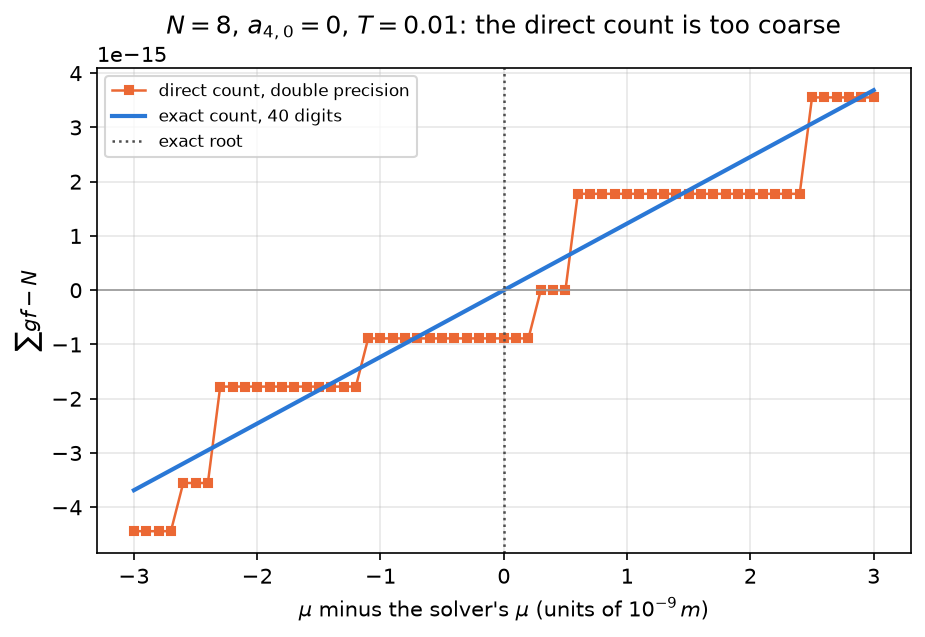

Figure 15d.1 saved as Revision/textbook/figures/15d_1_root_conditioning.png
RESULT width of the interval where the double-precision direct count is 0 = 3.0e-10 m
RESULT largest |balance root - 40-digit root| (20 states) = 9.3e-17
PASS the double-precision balance finds mu to 1e-15
     reproduces Revision/kohn_sham/reports/ks-rust-solver.json, check
    thermo_mu_well_conditioned_root


In [4]:
def balance_root(eps, deg, n, t):
    """mu from ln P = ln H (particles above = holes below the T = 0 filling)."""
    order = np.argsort(eps, kind="stable")
    e, g = np.array(eps)[order], np.array(deg)[order]
    filled = int(np.searchsorted(np.cumsum(g), n - 1e-9)) + 1  # T = 0 filling
    below_e, below_g, above_e, above_g = e[:filled], g[:filled], e[filled:], g[filled:]

    def log_sum(log_terms):  # ln(sum e^{t}) without overflow or underflow
        top = float(np.max(log_terms))
        return top + math.log(float(np.sum(np.exp(log_terms - top))))

    def log_f(x):  # ln f(x) = -ln(1 + e^{x}), stable for every x
        return -(np.maximum(x, 0.0) + np.log1p(np.exp(-np.abs(x))))

    def balance(mu):
        return (log_sum(np.log(above_g) + log_f((above_e - mu) / t))
                - log_sum(np.log(below_g) + log_f(-(below_e - mu) / t)))

    lo, hi = float(e[0]) - 1.0, float(e[-1]) + 1.0
    while lo < 0.5 * (lo + hi) < hi:  # bisection down to neighbouring numbers
        mid = 0.5 * (lo + hi)
        lo, hi = (mid, hi) if balance(mid) < 0.0 else (lo, mid)
    return lo


mu8, eps8, deg8, _ = states[(8, 0.0, 0.01)]
root8 = exact_root(eps8, deg8, 8, 0.01, mu8)
offsets = np.linspace(-3e-9, 3e-9, 61)
direct, exact = [], []
for off in offsets:
    x = (np.array(eps8) - (mu8 + off)) / 0.01
    direct.append(float(np.sum(np.array(deg8) / (1.0 + np.exp(x)))) - 8.0)
    with mpmath.workdps(40):
        m_ = mpmath.mpf(mu8) + mpmath.mpf(off)
        exact.append(float(sum(mpmath.mpf(g) / (1 + mpmath.exp((mpmath.mpf(e) - m_)
                                                                / mpmath.mpf(0.01)))
                               for e, g in zip(eps8, deg8)) - 8))
fig, ax = plt.subplots()
ax.plot(offsets * 1e9, direct, "s-", color=PALETTE[1], ms=4, lw=1.2,
        label="direct count, double precision")
ax.plot(offsets * 1e9, exact, color=PALETTE[0], lw=2.0, label="exact count, 40 digits")
ax.axvline(float(root8 - mu8) * 1e9, color="0.3", ls=":", lw=1.2, label="exact root")
ax.axhline(0.0, color="0.6", lw=0.8)
ax.set_xlabel("$\\mu$ minus the solver's $\\mu$ (units of $10^{-9}\\,m$)")
ax.set_ylabel("$\\sum g f - N$")
ax.set_title("$N = 8$, $a_{4,0} = 0$, $T = 0.01$: the direct count is too coarse")
ax.legend(fontsize=8)
save_figure(fig, "root_conditioning",
            "The particle-number condition $\\sum g f - N$ (vertical axis, of size "
            "$10^{-15}$) against $\\mu$ near its root (horizontal axis, in units of "
            "$10^{-9}\\,m$) for the activated state $N = 8$, $a_{4,0} = 0$, "
            "$T = 0.01$: computed directly in double precision it moves in steps of "
            "the rounding unit of $N$ (orange squares) and is zero on a whole "
            "interval, while the exact count (blue line, 40 digits) crosses zero at "
            "one point, which the balance of particles and holes finds.")
worst_balance = 0.0
for (n, a4, t), (mu, eps, deg, _) in states.items():
    root = exact_root(eps, deg, n, t, mu)
    worst_balance = max(worst_balance, float(abs(balance_root(eps, deg, n, t) - root)))
zero_width = (np.sum(np.array(direct) == 0.0)) * (offsets[1] - offsets[0])
report("width of the interval where the double-precision direct count is 0",
       f"{zero_width:.1e} m")
report(f"largest |balance root - 40-digit root| ({len(states)} states)",
       f"{worst_balance:.1e}")
check(worst_balance < 1e-15, "the double-precision balance finds mu to 1e-15",
      record="Revision/kohn_sham/reports/ks-rust-solver.json, check "
             "thermo_mu_well_conditioned_root")

## 8. The chemical potential as a function of temperature

With `balance_root` the next cell computes $\mu$ at 49 temperatures from $0.002$ to
$0.05$ for $N = 8$ at $a_{4,0} = 0$, $1$, $2$, using the level set of the solver at
$T = 0.05$ (the largest window; at lower temperatures the extra levels are empty to
far below the rounding). For $a_{4,0} = 0$ the two-level picture explains $\mu$:
the eight zero modes ($\varepsilon = 0$) lose as many particles as the 24 orbitals of
the first band level ($\varepsilon = \Delta = 0.4307$) gain, $8e^{-\mu/T} =
24e^{-(\Delta - \mu)/T}$, so $\mu = \Delta/2 - (T/2)\ln 3$ (the logarithm of the
ratio of degeneracies). The check compares this formula with the record at
$T = 0.01$.

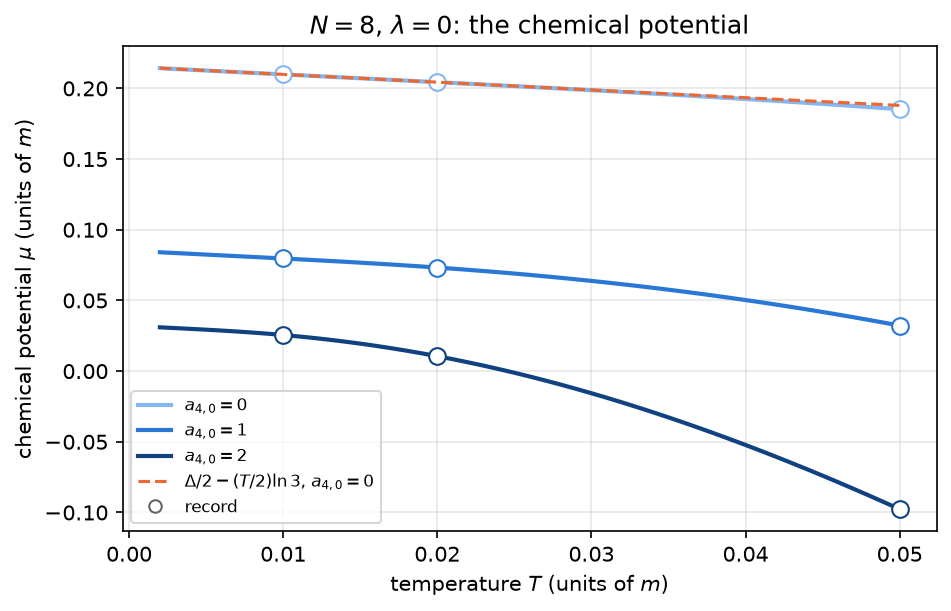

Figure 15d.2 saved as Revision/textbook/figures/15d_2_chemical_potential.png
RESULT mu of N8_lam0_a00_T10: two-level formula / record = 0.209873777875 /
    0.209873776387
PASS the two-level formula gives mu to 1e-8
     reproduces Revision/kohn_sham/results/thermo/thermodynamics.csv, N8_lam0_a00_T10


In [5]:
T_GRID = np.linspace(0.002, 0.05, 49)


def curves(n, a4):
    """mu, E, S, F, C_V on T_GRID from the solver's T = 0.05 level set."""
    _, eps, deg, _ = states[(n, a4, 0.05)]
    rows = []
    for t in T_GRID:
        mu = balance_root(eps, deg, n, t)
        energy, entropy, free, _, cv, _ = functions_of_state(eps, deg, mu, t)
        rows.append((mu, energy, entropy, free, cv))
    return np.array(rows)  # columns: mu, E, S, F, C_V


GROUND = "Revision/kohn_sham/results/ground/summary.csv"
with open(repository_file(GROUND), newline="", encoding="utf-8") as handle:
    ground = {row["id"]: row for row in csv.DictReader(handle)}
gap8 = float(ground["N8_lam0_a00"]["KS_gap"])
two_level = gap8 / 2.0 - 0.5 * T_GRID * math.log(3.0)
curve8 = {a4: curves(8, a4) for a4 in (0.0, 1.0, 2.0)}
fig, ax = plt.subplots()
for a4 in (0.0, 1.0, 2.0):
    ax.plot(T_GRID, curve8[a4][:, 0], color=SHADES[a4], lw=2.0,
            label=f"$a_{{4,0}} = {a4:.0f}$")
    ax.plot(TEMPS, [float(record[state_id(8, a4, t)]["mu"]) for t in TEMPS], "o",
            color=SHADES[a4], ms=8, markerfacecolor="white")
ax.plot(T_GRID, two_level, "--", color=PALETTE[1], lw=1.5,
        label="$\\Delta/2 - (T/2)\\ln 3$, $a_{4,0} = 0$")
ax.plot([], [], "o", color="0.4", markerfacecolor="white", label="record")
ax.set_xlabel("temperature $T$ (units of $m$)")
ax.set_ylabel("chemical potential $\\mu$ (units of $m$)")
ax.set_title("$N = 8$, $\\lambda = 0$: the chemical potential")
ax.legend(fontsize=8)
save_figure(fig, "chemical_potential",
            "The chemical potential $\\mu$ (vertical axis, units of $m$) of the free "
            "state $N = 8$ against the temperature $T$ (horizontal axis, units of "
            "$m$) at the slices $a_{4,0} = 0$, $1$, $2$ (lines: this notebook; open "
            "circles: the record). At $T \\to 0$ the chemical potential sits in the "
            "middle of the gap, $\\Delta/2$, and falls linearly with the slope "
            "$-(\\ln 3)/2$ (dashed, the two-level formula); the gap and with it "
            "$\\mu$ shrink along the history.")
formula = gap8 / 2.0 - 0.005 * math.log(3.0)
recorded = float(record[state_id(8, 0.0, 0.01)]["mu"])
report("mu of N8_lam0_a00_T10: two-level formula / record",
       f"{formula:.12f} / {recorded:.12f}")
check(abs(formula - recorded) < 1e-8, "the two-level formula gives mu to 1e-8",
      record=f"{THERMO}, N8_lam0_a00_T10")

## 9. Free energy and entropy along the history

The next cell computes the curves of $N = 136$ at the five slices and draws the
free energy measured from the ground-state energy, $F(T) - E_0$, and the entropy
$S(T)$; the record's values are the open circles. It also checks the thermodynamic
identity $-dF/dT = S$ with central differences $[F(T + h) - F(T - h)]/(2h)$,
$h = 10^{-3}T$, at every temperature of the grid.

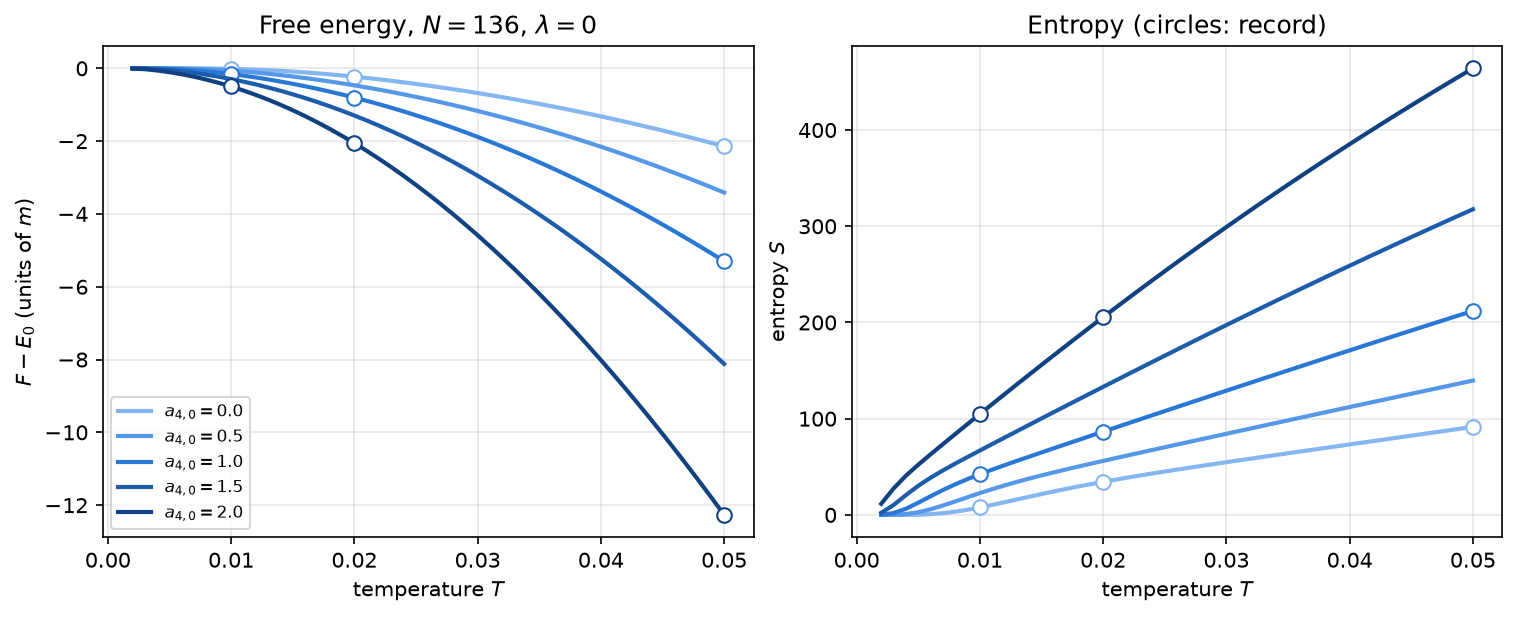

Figure 15d.3 saved as Revision/textbook/figures/15d_3_free_energy_entropy.png
RESULT largest relative |-dF/dT - S|, N = 136, a4,0 = 1 = 7.5e-06
PASS -dF/dT = S along the whole temperature grid
     reproduces Revision/kohn_sham/reports/ks-rust-solver.json, check
    thermo_entropy_identity
PASS S rises and F falls with T at every slice


In [6]:
curve136 = {a4: curves(136, a4) for a4 in (0.0, 0.5, 1.0, 1.5, 2.0)}
fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.0), layout="constrained")
for a4, values in curve136.items():
    e0 = float(ground[f"N136_lam0_a{round(10 * a4):02d}"]["E_KS"])
    left.plot(T_GRID, values[:, 3] - e0, color=SHADES[a4], lw=2.0,
              label=f"$a_{{4,0}} = {a4}$")
    right.plot(T_GRID, values[:, 2], color=SHADES[a4], lw=2.0)
    if a4 in (0.0, 1.0, 2.0):
        ids = [state_id(136, a4, t) for t in TEMPS]
        left.plot(TEMPS, [float(record[i]["F"]) - e0 for i in ids], "o",
                  color=SHADES[a4], ms=7, markerfacecolor="white")
        right.plot(TEMPS, [float(record[i]["entropy"]) for i in ids], "o",
                   color=SHADES[a4], ms=7, markerfacecolor="white")
left.set_xlabel("temperature $T$")
left.set_ylabel("$F - E_0$ (units of $m$)")
left.set_title("Free energy, $N = 136$, $\\lambda = 0$")
left.legend(fontsize=8)
right.set_xlabel("temperature $T$")
right.set_ylabel("entropy $S$")
right.set_title("Entropy (circles: record)")
save_figure(fig, "free_energy_entropy",
            "Left: the free energy measured from the ground-state energy, "
            "$F - E_0$ (vertical axis, units of $m$), of the free state $N = 136$ at "
            "the five slices (light to dark blue) against the temperature (horizontal "
            "axis, units of $m$). Right: the entropy $S$ (pure number). Circles: the "
            "record. Along the history the levels crowd together, so the same "
            "temperature excites more particles: the entropy grows and the free "
            "energy falls faster.")
_, eps, deg, _ = states[(136, 1.0, 0.05)]
worst_fs = 0.0
for t in T_GRID:
    h = 1e-3 * t
    f_plus = functions_of_state(eps, deg, balance_root(eps, deg, 136, t + h), t + h)[2]
    f_minus = functions_of_state(eps, deg, balance_root(eps, deg, 136, t - h), t - h)[2]
    s = functions_of_state(eps, deg, balance_root(eps, deg, 136, t), t)[1]
    worst_fs = max(worst_fs, abs(-(f_plus - f_minus) / (2 * h) - s) / s)
report("largest relative |-dF/dT - S|, N = 136, a4,0 = 1", f"{worst_fs:.1e}")
check(worst_fs < 1e-4, "-dF/dT = S along the whole temperature grid",
      record="Revision/kohn_sham/reports/ks-rust-solver.json, check "
             "thermo_entropy_identity")
rising = all(bool(np.all(np.diff(v[:, 2]) > 0)) and bool(np.all(np.diff(v[:, 3]) < 0))
             for v in curve136.values())
check(rising, "S rises and F falls with T at every slice")

## 10. The heat capacity

The next cell draws $C_V(T)$ (closed form) for $N = 8$ at three slices (left) and
$N = 136$ at five slices (right), on logarithmic vertical axes, with the record's
values. For $N = 8$ at $a_{4,0} = 0$ the gas is **activated**: below $T \approx 0.02$
the heat capacity is tiny, because the first excitation costs the gap $0.43\,m$.
Along the history the gap closes and the heat capacity rises at lower temperatures.
$N = 136$ has a much smaller gap ($0.083\,m$ at $a_{4,0} = 0$, $0.014\,m$ at $2$) and
a large heat capacity already at $T = 0.01$.

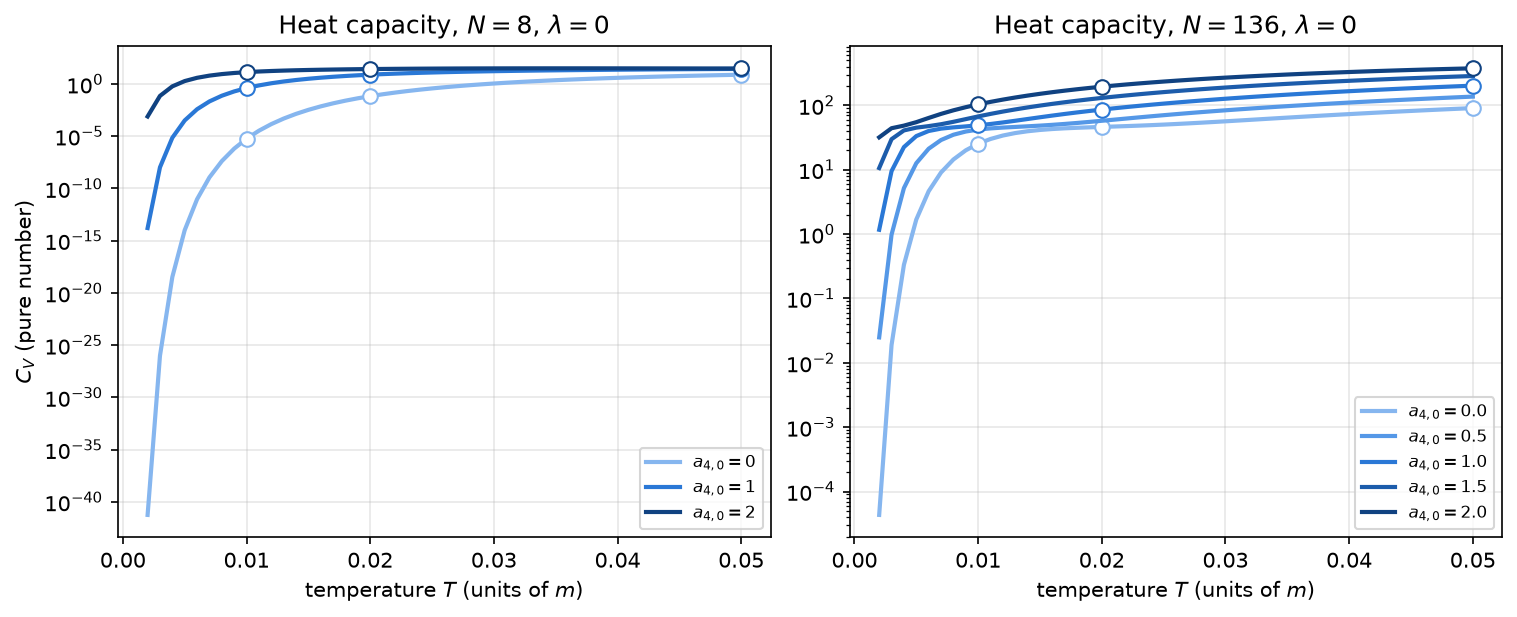

Figure 15d.4 saved as Revision/textbook/figures/15d_4_heat_capacity.png
PASS C_V > 0 at every temperature and slice


In [7]:
fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.0), layout="constrained")
for a4, values in curve8.items():
    left.plot(T_GRID, values[:, 4], color=SHADES[a4], lw=2.0,
              label=f"$a_{{4,0}} = {a4:.0f}$")
    left.plot(TEMPS, [float(record[state_id(8, a4, t)]["C_V"]) for t in TEMPS], "o",
              color=SHADES[a4], ms=7, markerfacecolor="white")
for a4, values in curve136.items():
    right.plot(T_GRID, values[:, 4], color=SHADES[a4], lw=2.0,
               label=f"$a_{{4,0}} = {a4}$")
    if a4 in (0.0, 1.0, 2.0):
        right.plot(TEMPS, [float(record[state_id(136, a4, t)]["C_V"]) for t in TEMPS],
                   "o", color=SHADES[a4], ms=7, markerfacecolor="white")
for ax, n in ((left, 8), (right, 136)):
    ax.set_yscale("log")
    ax.set_xlabel("temperature $T$ (units of $m$)")
    ax.set_title(f"Heat capacity, $N = {n}$, $\\lambda = 0$")
    ax.legend(fontsize=8)
left.set_ylabel("$C_V$ (pure number)")
save_figure(fig, "heat_capacity",
            "The heat capacity $C_V = dE/dT$ (vertical axis, logarithmic, pure "
            "number) of the free states $N = 8$ (left, three slices) and $N = 136$ "
            "(right, five slices) against the temperature (horizontal axis, units "
            "of $m$); circles: the record. The gas $N = 8$ is activated across its "
            "gap of $0.43\\,m$ at $a_{4,0} = 0$; as the history closes the gaps, "
            "the heat capacity rises at ever lower temperatures.")
positive = all(bool(np.all(v[:, 4] > 0)) for v in list(curve8.values())
               + list(curve136.values()))
check(positive, "C_V > 0 at every temperature and slice")

## 11. What the occupations look like

The next cell draws the occupation $f$ of every level of $N = 136$ at
$a_{4,0} = 1$ against its energy, at the three temperatures of the record, with the
chemical potential marked: the step of the Fermi-Dirac function softens over a width
of a few $T$. The check confirms that the occupations add up to $N = 136$.

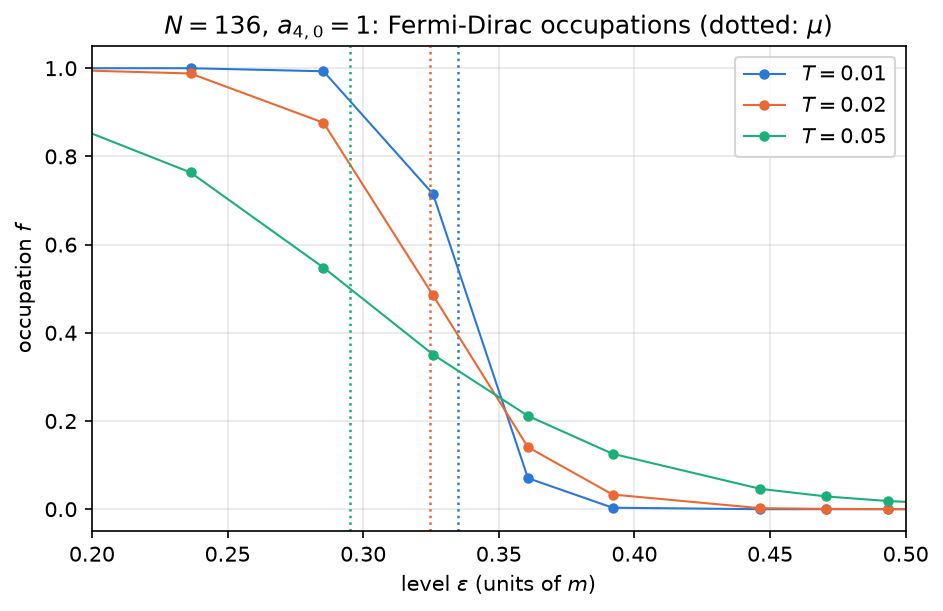

Figure 15d.5 saved as Revision/textbook/figures/15d_5_occupations.png
RESULT sum g f at the three temperatures = 136.000000000000, 136.000000000000,
    136.000000000000
PASS the occupations add up to N = 136
     reproduces Revision/kohn_sham/reports/ks-rust-solver.json, check
    thermo_N_conservation


In [8]:
fig, ax = plt.subplots()
sums = []
for colour, t in zip(PALETTE, TEMPS):
    mu, eps, deg, levels = states[(136, 1.0, t)]
    e = np.array(eps)
    f = 1.0 / (1.0 + np.exp(np.minimum((e - mu) / t, 700.0)))
    sums.append(float(np.sum(np.array(deg) * f)))
    order = np.argsort(e)
    ax.plot(e[order], f[order], "o-", color=colour, ms=4, lw=1.0, label=f"$T = {t}$")
    ax.axvline(mu, color=colour, ls=":", lw=1.2)
ax.set_xlim(0.2, 0.5)
ax.set_xlabel("level $\\varepsilon$ (units of $m$)")
ax.set_ylabel("occupation $f$")
ax.set_title("$N = 136$, $a_{4,0} = 1$: Fermi-Dirac occupations (dotted: $\\mu$)")
ax.legend()
save_figure(fig, "occupations",
            "The occupation $f$ of the levels of the free state $N = 136$ at "
            "$a_{4,0} = 1$ (vertical axis) against their energy (horizontal axis, "
            "units of $m$, near the Fermi level) at the temperatures $T = 0.01$, "
            "$0.02$, $0.05$; dotted lines: the chemical potentials. The step from "
            "full to empty widens with the temperature, over a few $T$.")
report("sum g f at the three temperatures", ", ".join(f"{s:.12f}" for s in sums))
check(max(abs(s - 136.0) for s in sums) < 1e-9, "the occupations add up to N = 136",
      record="Revision/kohn_sham/reports/ks-rust-solver.json, check "
             "thermo_N_conservation")

## 12. The filling convention and its sea holes

The convention fills only the positive branch. The sea's brane band (block type
$j = -1$, even parity, label 0) has, without interaction, exactly the energies
$-\varepsilon_{band}(n_2)$ of the brane band of $j = +1$ (the block Hamiltonians obey
$h_{-1} = -h_{+1}$ when $v = 0$). If the sea were treated thermally, its levels would
carry holes with the probability $1 - f(-\varepsilon_{band}) =
1/(1 + e^{(\mu + \varepsilon_{band})/T})$. The next cell adds up
$4 r_3(n_2)$ times this probability over the shells $n_2 \ge 1$ of the level set and
compares with the record's column `sea_holes_excluded` for $N = 8$ at $T = 0.05$. The
figure shows the record's number of sea holes per particle for $N = 8$ and $136$ at
all slices and temperatures: above about 1 percent (dotted line) the particle-only
ensemble is outside its range of validity, and a thermal treatment of the sea
(particle-antiparticle pairs) would be needed.

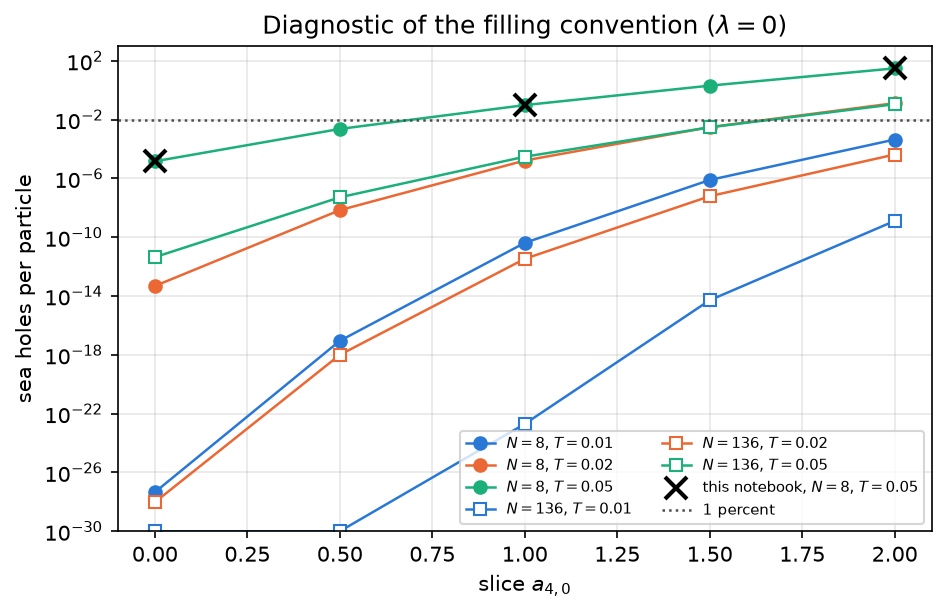

Figure 15d.6 saved as Revision/textbook/figures/15d_6_sea_holes.png
RESULT sea holes per particle, N = 8, T = 0.05, a4,0 = 0, 1, 2 = 1.464e-05, 0.09746, 30.8
PASS the sea-hole diagnostic reproduced
     reproduces Revision/kohn_sham/results/thermo/thermodynamics.csv, column
    sea_holes_excluded


In [9]:
def shell_sizes(largest):
    """r3(n2): the number of whole-number vectors with n2 = |n|^2, n2 <= largest."""
    reach = math.isqrt(largest) + 1
    sizes = {}
    for x in range(-reach, reach + 1):
        for y in range(-reach, reach + 1):
            for z in range(-reach, reach + 1):
                s = x * x + y * y + z * z
                if s <= largest:
                    sizes[s] = sizes.get(s, 0) + 1
    return sizes


worst_sea, mine = 0.0, {}
for a4 in (0.0, 1.0, 2.0):
    mu, _, _, levels = states[(8, a4, 0.05)]
    band = {lv[0]: lv[4] for lv in levels
            if lv[1] == 1 and lv[2] == "even" and lv[3] == 0 and lv[0] >= 1}
    sizes = shell_sizes(max(lv[0] for lv in levels))
    holes = sum(4 * sizes[n2] / (1.0 + math.exp((mu + band[n2]) / 0.05))
                for n2 in sizes if n2 >= 1)
    mine[a4] = holes / 8.0
    recorded = float(record[state_id(8, a4, 0.05)]["sea_holes_excluded"])
    worst_sea = max(worst_sea, abs(holes / recorded - 1.0))
fig, ax = plt.subplots()
for marker, n in (("o", 8), ("s", 136)):
    for colour, t in zip(PALETTE, TEMPS):
        values = [float(record[state_id(n, a, t)]["sea_holes_over_N"])
                  for a in (0.0, 0.5, 1.0, 1.5, 2.0)]
        ax.plot([0, 0.5, 1, 1.5, 2], np.maximum(values, 1e-30), marker + "-",
                color=colour, ms=6, lw=1.2,
                markerfacecolor=colour if n == 8 else "white",
                label=f"$N = {n}$, $T = {t}$")
ax.plot(list(mine), list(mine.values()), "x", color="black", ms=11, mew=2,
        label="this notebook, $N = 8$, $T = 0.05$")
ax.axhline(0.01, color="0.3", ls=":", lw=1.2, label="1 percent")
ax.set_yscale("log")
ax.set_ylim(1e-30, 1e3)
ax.set_xlabel("slice $a_{4,0}$")
ax.set_ylabel("sea holes per particle")
ax.set_title("Diagnostic of the filling convention ($\\lambda = 0$)")
ax.legend(fontsize=7, ncol=2, loc="lower right")
save_figure(fig, "sea_holes",
            "The number of thermal holes that the excluded sea brane band would "
            "carry, per particle (vertical axis, logarithmic), for $N = 8$ (filled) "
            "and $N = 136$ (open) at $T = 0.01$, $0.02$, $0.05$ against the slice "
            "(horizontal axis), from the record; crosses: recomputed here. Above the "
            "dotted 1 percent line, reached late in the history at the higher "
            "temperatures, the particle-only convention is outside its range of "
            "validity.")
report("sea holes per particle, N = 8, T = 0.05, a4,0 = 0, 1, 2",
       ", ".join(f"{v:.4g}" for v in mine.values()))
check(worst_sea < 1e-9, "the sea-hole diagnostic reproduced",
      record=f"{THERMO}, column sea_holes_excluded")

## 13. The interaction at finite temperature

The last figure uses only the record: the change of the free energy caused by the
couplings $\pm\lambda_1$, $F(\lambda) - F(0)$, for $N = 8$, $136$ and $688$ at the
first slice and the three temperatures. The interaction changes $F$ by less than
$0.005\,m$; repulsion raises it for $N = 136$ and $688$ and lowers it for $N = 8$
(the zero-mode state, whose interaction energy is an exchange energy).

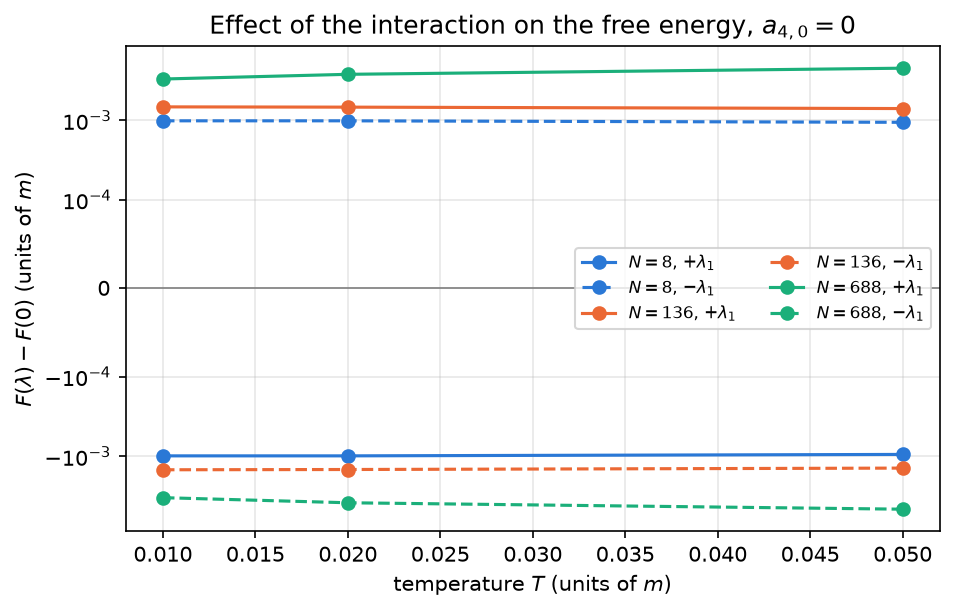

Figure 15d.7 saved as Revision/textbook/figures/15d_7_interaction_free_energy.png
RESULT largest |F(lambda) - F(0)| at a4,0 = 0 = 0.0046
PASS the interaction changes F by less than 0.005 at a4,0 = 0


In [10]:
fig, ax = plt.subplots()
shifts = []
for colour, n in zip(PALETTE, (8, 136, 688)):
    for tag, style in (("lamp1", "-"), ("lamm1", "--")):
        values = [float(record[state_id(n, 0.0, t, tag)]["F"])
                  - float(record[state_id(n, 0.0, t)]["F"]) for t in TEMPS]
        shifts += values
        sign = "+" if tag == "lamp1" else "-"
        ax.plot(TEMPS, values, style, marker="o", color=colour, ms=6, lw=1.5,
                label=f"$N = {n}$, ${sign}\\lambda_1$")
ax.set_yscale("symlog", linthresh=1e-4)
ax.axhline(0.0, color="0.5", lw=0.8)
ax.set_xlabel("temperature $T$ (units of $m$)")
ax.set_ylabel("$F(\\lambda) - F(0)$ (units of $m$)")
ax.set_title("Effect of the interaction on the free energy, $a_{4,0} = 0$")
ax.legend(fontsize=8, ncol=2)
save_figure(fig, "interaction_free_energy",
            "The change of the free energy caused by the couplings $+\\lambda_1$ "
            "(solid) and $-\\lambda_1$ (dashed), $F(\\lambda) - F(0)$ (vertical axis, "
            "symmetric logarithmic, units of $m$), for $N = 8$, $136$, $688$ at "
            "$a_{4,0} = 0$ against the temperature (horizontal axis), from the "
            "record. The effect is small and nearly independent of $T$; its sign "
            "follows the coupling, opposite for $N = 8$.")
report("largest |F(lambda) - F(0)| at a4,0 = 0", f"{max(abs(s) for s in shifts):.4f}")
check(max(abs(s) for s in shifts) < 0.005,
      "the interaction changes F by less than 0.005 at a4,0 = 0")

## 14. The last check

The last cell checks that every figure file of this notebook exists and prints the
number of checks that passed.

In [11]:
NAMES = ["root_conditioning", "chemical_potential", "free_energy_entropy",
         "heat_capacity", "occupations", "sea_holes", "interaction_free_energy"]
missing = [name for number, name in enumerate(NAMES, start=1)
           if not output_file(f"{FIGURE_FOLDER}/15d_{number}_{name}.png").is_file()]
check(missing == [], "every figure file of this notebook exists")
all_checks_passed()

PASS every figure file of this notebook exists
ALL 14 CHECKS PASSED (notebook 15d)


## 15. What this notebook showed

- From the solver's levels alone, plain Python reproduces the chemical potential,
  energy, entropy, free energy, grand potential, heat capacity and $dN/d\mu$ of the
  free thermal states of the record (COMPUTED).
- The solver's chemical potential lies within its rounding bound of the 40-digit
  root; the direct count in double precision could not do this, which is why the
  solver balances thermal particles against thermal holes.
- $\mu$ starts in the middle of the gap and falls with $T$; along the deflating
  history the gaps close, so the entropy rises, the free energy falls faster and the
  heat capacity rises at lower temperatures; $-dF/dT = S$ holds.
- The particle-only filling is a CONVENTION; late in the history at the higher
  temperatures the excluded sea would carry many holes (up to 31 per particle for
  $N = 8$), and there the convention is outside its range of validity (OPEN: a
  thermal treatment of the sea).
- These are instantaneous states on a PRESCRIBED background, with the brane
  ASSUMED.